In [77]:
from ml_enhance import load_hpc_result, compare, CorrelationFilter, FeatureImportance
from math import floor
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
from dataclasses import dataclass
import numpy as np
import json

In [102]:
@dataclass
class ModelConfig:
    mean_col: str
    std_col: str
    label: str
    color: str
    marker: str = "o"
    zorder: int = 3

In [199]:
def combine_model_dfs(model_dfs: dict[str, pd.DataFrame], metric: str) -> pd.DataFrame:
    """
    Combines per-model DataFrames into a single wide DataFrame with mean/std per model.

    Args:
        model_dfs: dict mapping model name to its DataFrame.

    Returns:
        Wide DataFrame with num_samples + {name}_mean + {name}_std columns.
    """
    n_tot = 8759 # 8763 before rerun
    n_train = floor(n_tot * (4/5))
    
    agg_dfs = []
    for name, df in model_dfs.items():
        agg = (
            df.groupby("size")[metric]
            .agg(mean="mean", std="std", count="count")
            .reset_index()
            .rename(columns={
                "mean": f"{name}_mean",
                "std": f"{name}_std",
                "count": f"{name}_count",
            })
        )

        agg_dfs.append(agg)

    combined = agg_dfs[0]
    for agg in agg_dfs[1:]:
        combined = combined.merge(agg, on="size")
    
    combined.insert(1, "num_samples", combined["size"].apply(lambda size: size * n_train))

    return combined

In [195]:
def plot_size_evo(ax: plt.Axes, df: pd.DataFrame, models: list[ModelConfig]) -> None:
    for model in models:
        ax.errorbar(
            df["num_samples"],
            df[model.mean_col],
            yerr=df[model.std_col],
            fmt="none",
            ecolor=model.color,
            capsize=4,
            alpha=0.8,
            zorder=1,
        )

    for model in models:
        sns.scatterplot(
            ax=ax,
            data=df,
            x="num_samples",
            y=model.mean_col,
            color=model.color,
            s=80,
            label=model.label,
            zorder=model.zorder,
            marker=model.marker,
        )

    ax.tick_params(axis="both", labelsize=14)
    
    ax.set_xlabel("Number of training samples", fontsize=18)
    ax.set_ylabel("Score", fontsize=18)
    ax.legend(fontsize=14)

In [90]:
def remove_neg_r2(combo_df: pd.DataFrame, topo_df: pd.DataFrame, print_dropped: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    num_negs_combo = set(combo_df.index[combo_df["test_r2"] < 0])
    num_negs_topo = set(topo_df.index[topo_df["test_r2"] < 0])

    neg_nums = list(num_negs_combo | num_negs_topo)

    if print_dropped:
        for fold_id, size in combo_df.loc[neg_nums, ["fold_id", "size"]].values:
            print(f"Sample with {fold_id = :.0f} and {size = :.2f} was dropped due to negative 'test_r2'.")

    return combo_df.drop(neg_nums), topo_df.drop(neg_nums)

In [ ]:
HuberReg_combo_df = load_hpc_result(Path("../data/HuberReg_results/2_HuberReg_combo_rerun_results.pkl"), "HuberReg_topo+QM", id_as_index=False)
HuberReg_topo_df = load_hpc_result(Path("../data/HuberReg_results/2_HuberReg_topo_rerun_results.pkl"), "HuberReg_topo", id_as_index=False)
HuberReg_combo_df_pos, HuberReg_topo_df_pos = remove_neg_r2(HuberReg_combo_df, HuberReg_topo_df, print_dropped=False)


KRR_combo_df = load_hpc_result(Path("../data/KRR_results/2_KRR_combo_rerun_results.pkl"), "KRR_topo+QM", id_as_index=False)
KRR_topo_df = load_hpc_result(Path("../data/KRR_results/2_KRR_topo_rerun_results.pkl"), "KRR_topo", id_as_index=False)
KRR_combo_df_pos, KRR_topo_df_pos = remove_neg_r2(KRR_combo_df, KRR_topo_df, print_dropped=False)


chemprop_baseline_df = pd.read_json("../data/chemprop_results/2_chemprop_no_added_w_charge_rerun_results.json")
chemprop_rdkit_df = pd.read_json("../data/chemprop_results/2_chemprop_w_rdkit_rerun_results.json")
chemprop_atom_df = pd.read_json("../data/chemprop_results/2_chemprop_atom_feat_rerun_results.json")
chemprop_full_df = pd.read_json("../data/chemprop_results/2_chemprop_full_feat_rerun_results.json")

,size,num_samples,HuberReg_combo_mean,HuberReg_combo_std,HuberReg_combo_count,HuberReg_topo_mean,HuberReg_topo_std,HuberReg_topo_count,KRR_combo_mean,KRR_combo_std,KRR_combo_count,KRR_topo_mean,KRR_topo_std,KRR_topo_count
0,0.025,175.175,0.166883,0.148355,5,0.442381,0.061507,5,0.639945,0.077691,18,0.659361,0.031830,18
1,0.050,350.350,0.511170,0.164615,8,0.570819,0.230516,8,0.717180,0.019310,23,0.720337,0.030960,23
2,0.075,525.525,0.572857,0.181329,12,0.704117,0.040346,12,0.748673,0.022486,25,0.750313,0.029495,25
3,0.100,700.700,0.631541,0.185547,16,0.728752,0.037694,16,0.776849,0.022496,25,0.774775,0.025076,25
4,0.150,1051.050,0.645235,0.175045,17,0.740203,0.046969,17,0.803734,0.014443,25,0.798020,0.016069,25
5,0.200,1401.400,0.705432,0.090187,17,0.754483,0.031152,17,0.813948,0.012518,25,0.807124,0.014415,25
6,0.250,1751.750,0.720998,0.086752,18,0.765653,0.024521,18,0.824056,0.013348,25,0.815400,0.011666,25
7,0.500,3503.500,0.771173,0.072214,18,0.779258,0.019165,18,0.847343,0.009745,25,0.836422,0.009887,25
8,0.600,4204.200,0.766771,0.086665,18,0.777930,0.016276,18,0.852894,0.009046,25,0.841209,0.008499,25
9,0.750,5255.250,0.782615,0.034229,18,0.777984,0.015527,18,0.858017,0.009883,25,0.846668,0.008866,25


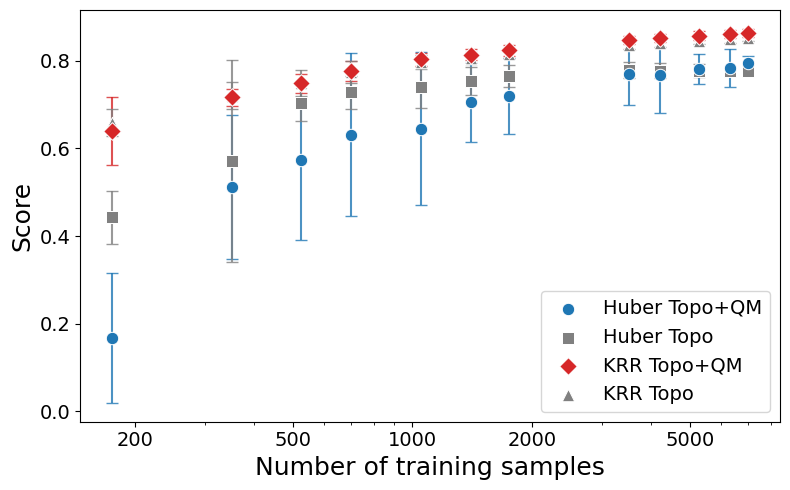

In [ ]:
from matplotlib.ticker import LogLocator, ScalarFormatter

model_dfs = {
    "HuberReg_combo": HuberReg_combo_df_pos,
    "HuberReg_topo":  HuberReg_topo_df_pos,
    "KRR_combo": KRR_combo_df_pos,
    "KRR_topo":  KRR_topo_df_pos,
    
}

combined_df = combine_model_dfs(model_dfs, "test_r2")

display(combined_df)

models = [
    ModelConfig(mean_col="HuberReg_combo_mean", std_col="HuberReg_combo_std", label="Huber Topo+QM", color="tab:blue", zorder=2),
    ModelConfig(mean_col="HuberReg_topo_mean", std_col="HuberReg_topo_std", label="Huber Topo", color="grey", marker="s", zorder=1),
    ModelConfig(mean_col="KRR_combo_mean", std_col="KRR_combo_std", label="KRR Topo+QM", color="tab:red", marker="D", zorder=4),
    ModelConfig(mean_col="KRR_topo_mean", std_col="KRR_topo_std", label="KRR Topo", color="grey", marker="^", zorder=3),
]


fig, ax = plt.subplots(figsize=(8, 5))

plot_size_evo(ax, combined_df, models)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

,size,num_samples,chemprop_baseline_mean,chemprop_baseline_std,chemprop_baseline_count,chemprop_rdkit_mean,chemprop_rdkit_std,chemprop_rdkit_count,chemprop_full_mean,chemprop_full_std,chemprop_full_count
0,0.025,175.175,0.640723,0.034979,25,0.711631,0.034958,25,0.351404,1.123589,25
1,0.050,350.350,0.701268,0.036377,25,0.752711,0.019630,25,0.600166,0.603998,25
2,0.075,525.525,0.731178,0.041169,25,0.768609,0.046072,25,0.723433,0.176855,25
3,0.100,700.700,0.748232,0.029990,24,0.789655,0.016487,25,0.760652,0.052419,25
4,0.150,1051.050,0.772941,0.032839,25,0.809545,0.014832,25,0.792364,0.021672,25
5,0.200,1401.400,0.786076,0.034088,25,0.821201,0.010689,25,0.798851,0.035134,25
6,0.250,1751.750,0.797134,0.033477,25,0.831107,0.013177,25,0.787560,0.132581,25
7,0.500,3503.500,0.817991,0.023937,25,0.848749,0.012754,25,0.831479,0.029032,25
8,0.600,4204.200,0.833820,0.013337,25,0.858594,0.009000,25,0.843172,0.012623,25
9,0.750,5255.250,0.845423,0.012188,25,0.865354,0.009023,25,0.847831,0.012831,25


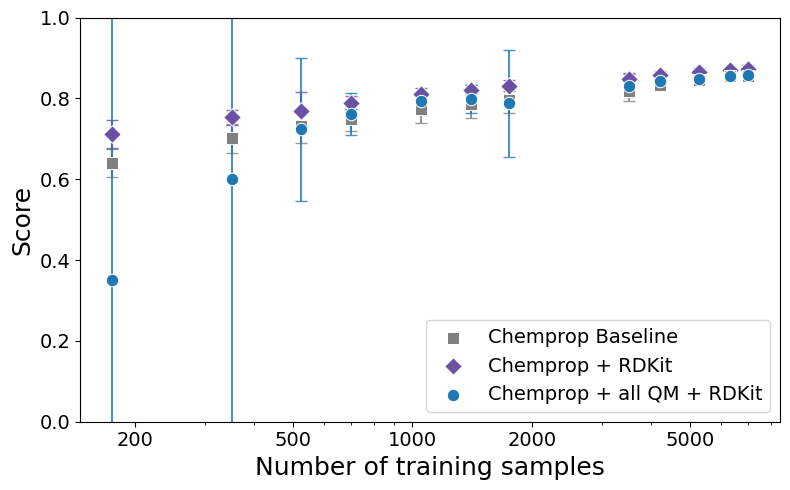

In [220]:
model_dfs = {
    "chemprop_baseline":  chemprop_baseline_df,
    "chemprop_rdkit": chemprop_rdkit_df,
    # "chemprop_atom":  chemprop_atom_df,
    "chemprop_full": chemprop_full_df,
    
}

combined_df = combine_model_dfs(model_dfs, "r2_test")

display(combined_df)

models = [
    ModelConfig(mean_col="chemprop_baseline_mean", std_col="chemprop_baseline_std", label="Chemprop Baseline", color="grey", marker="s", zorder=3),
    ModelConfig(mean_col="chemprop_rdkit_mean", std_col="chemprop_rdkit_std", label="Chemprop + RDKit", color="#6a51a3", marker="D", zorder=2),
    # ModelConfig(mean_col="chemprop_atom_mean", std_col="chemprop_atom_std", label="Chemprop + atom QM", color="tab:red", marker="^", zorder=4),
    ModelConfig(mean_col="chemprop_full_mean", std_col="chemprop_full_std", label="Chemprop + all QM + RDKit", color="tab:blue", zorder=4),
]

fig, ax = plt.subplots(figsize=(8, 5))

plot_size_evo(ax, combined_df, models)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(ScalarFormatter())

ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Kernel Ridge Regression

In [29]:
KRR_combined_df = make_combined_df(KRR_combo_filtered_df_pos, KRR_topo_filtered_df_pos, metric="test_r2")
KRR_plot_df = KRR_combined_df.drop([0.025, 0.05, 0.075])
KRR_plot_df

,combo_mean,combo_std,topo_mean,topo_std,diff,num_samples,num_scores
size,,,,,,,
0.10,0.789265,0.012541,0.780930,0.015397,0.008335,876,22
0.15,0.804369,0.012167,0.801830,0.016007,0.002539,1314,25
0.20,0.813814,0.011373,0.811786,0.014081,0.002028,1752,25
0.25,0.822471,0.010408,0.821599,0.010107,0.000872,2190,25
0.50,0.845760,0.010255,0.842313,0.009569,0.003447,4381,25
0.60,0.851780,0.010113,0.847748,0.009233,0.004032,5257,25
0.75,0.859533,0.008503,0.854172,0.009513,0.005362,6572,25
0.90,0.864036,0.007749,0.858985,0.008434,0.005051,7886,25
1.00,0.866426,0.008988,0.861859,0.008829,0.004567,8763,25


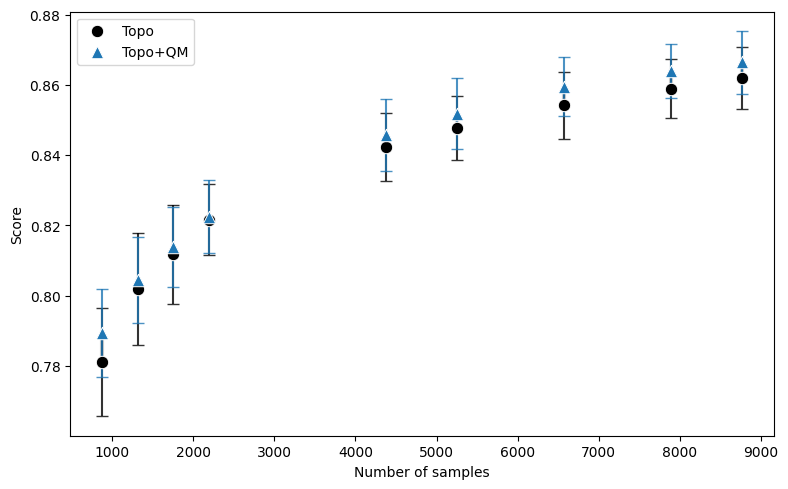

In [30]:
plot_size_evo(KRR_plot_df)
# plt.xscale("log")

Text(0, 0.5, 'Score Difference')

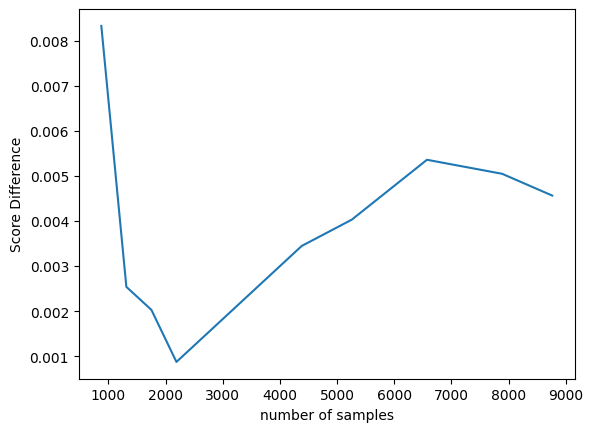

In [31]:
plt.plot(KRR_plot_df["num_samples"], KRR_plot_df["diff"])
plt.xlabel("number of samples")
plt.ylabel("Score Difference")

In [32]:
from math import ceil, floor

krr_combo_groups = KRR_combo_filtered_df_pos.groupby("size")
krr_topo_groups = KRR_topo_filtered_df_pos.groupby("size")

for size in KRR_plot_df.index:
    print(f"------ {size = } ------")
    n_tot = 8763

    n_train = floor(floor(n_tot * 0.8) * size)
    n_test = ceil(n_tot * 0.2)


    compare(
        krr_combo_groups.get_group(size).reset_index(),
        krr_topo_groups.get_group(size).reset_index(),
        n_train=n_train,
        n_test=n_test
    )

    print("\n\n\n")

------ size = 0.1 ------
KRR_topo+QM_filtered mean r2: 0.7892647162736371 (Train: 0.9175844746410319)
KRR_topo mean r2: 0.7809295642496935 (Train: 0.9225447813569062)
Mean improvement: 0.008335152023943542
T-test p-value: 0.001767135127438868 -> statistically significant
Wilcoxon p-value: 4.76837158203125e-07 -> statistically significant


KRR_topo+QM_filtered mean MSE: 1.1236392864747105 (Train: 0.43694732125198127)
KRR_topo mean MSE: 1.1681870406089887 (Train: 0.4103778738768995)
Mean improvement: -0.04454775413427802
T-test p-value: 0.001857415295989151 -> statistically significant
Wilcoxon p-value: 4.76837158203125e-07 -> statistically significant






------ size = 0.15 ------
KRR_topo+QM_filtered mean r2: 0.8043691985527026 (Train: 0.941644588966214)
KRR_topo mean r2: 0.8018299646861615 (Train: 0.9533521363433554)
Mean improvement: 0.0025392338665412104
T-test p-value: 0.2785290758844887 -> not statistically significant
Wilcoxon p-value: 0.14091521501541138 -> not statistically 

------ size = 0.1 ------


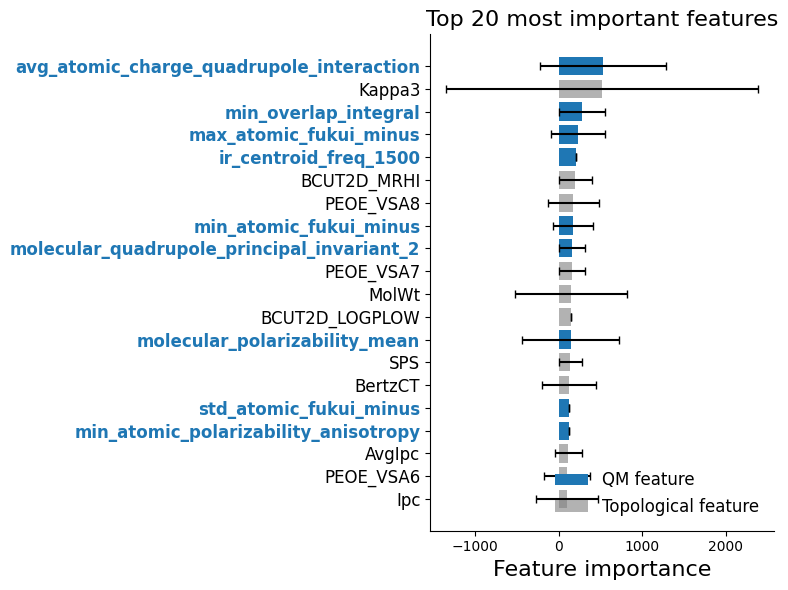

------ size = 0.15 ------


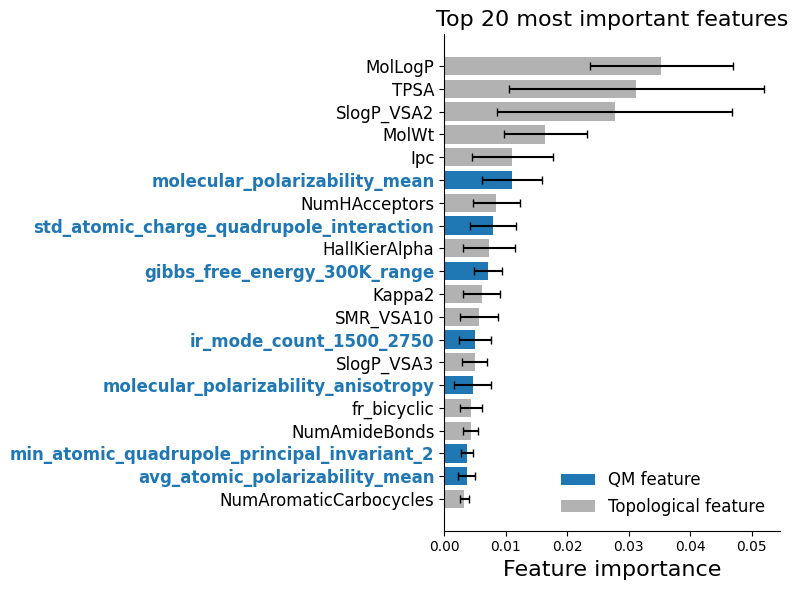

------ size = 0.2 ------


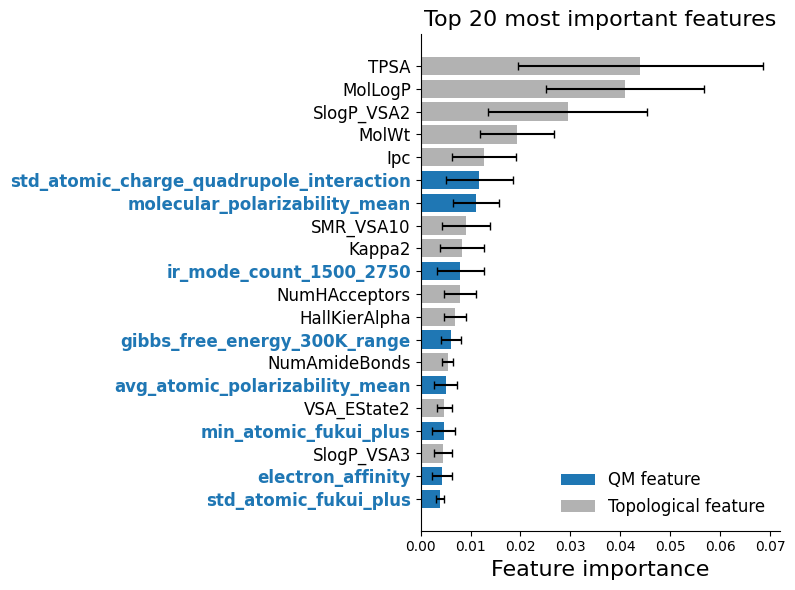

------ size = 0.25 ------


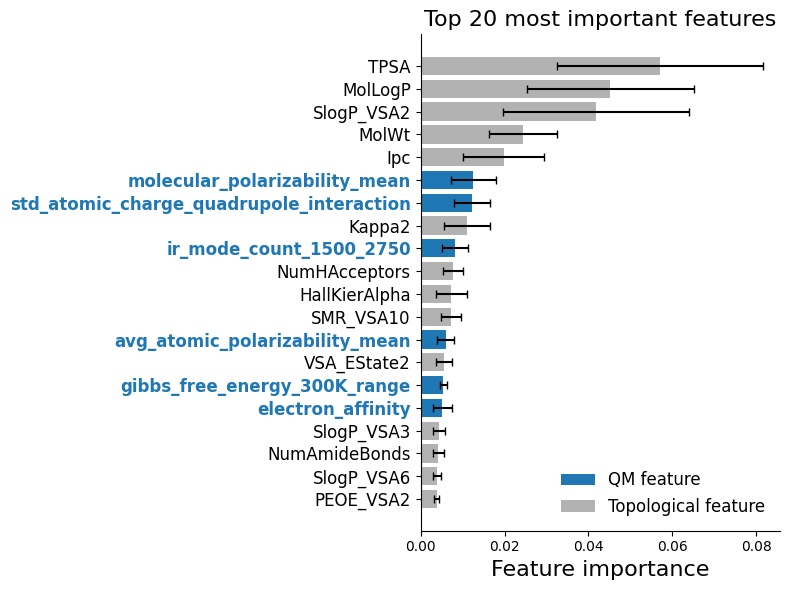

------ size = 0.5 ------


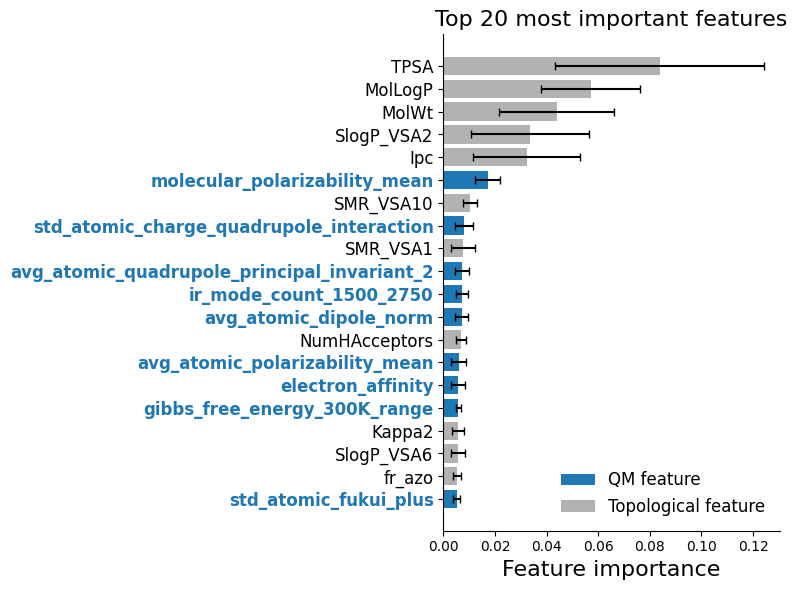

------ size = 0.6 ------


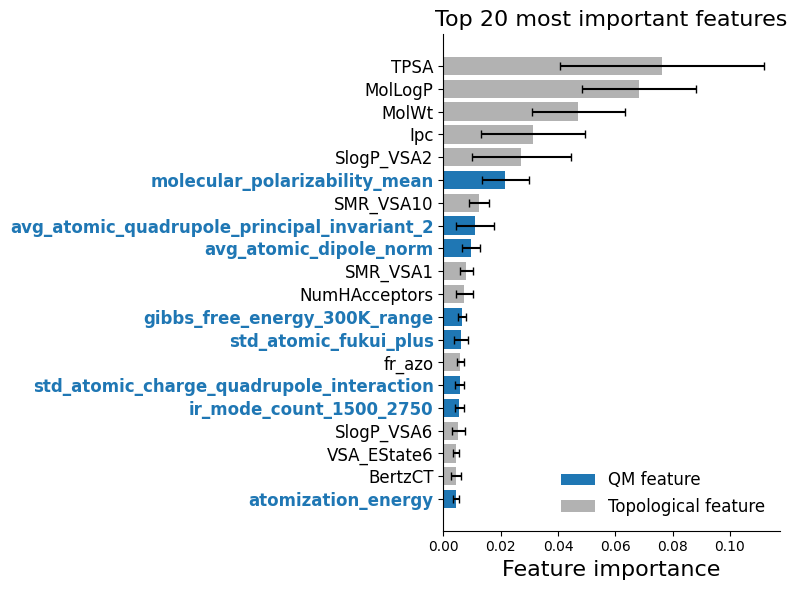

------ size = 0.75 ------


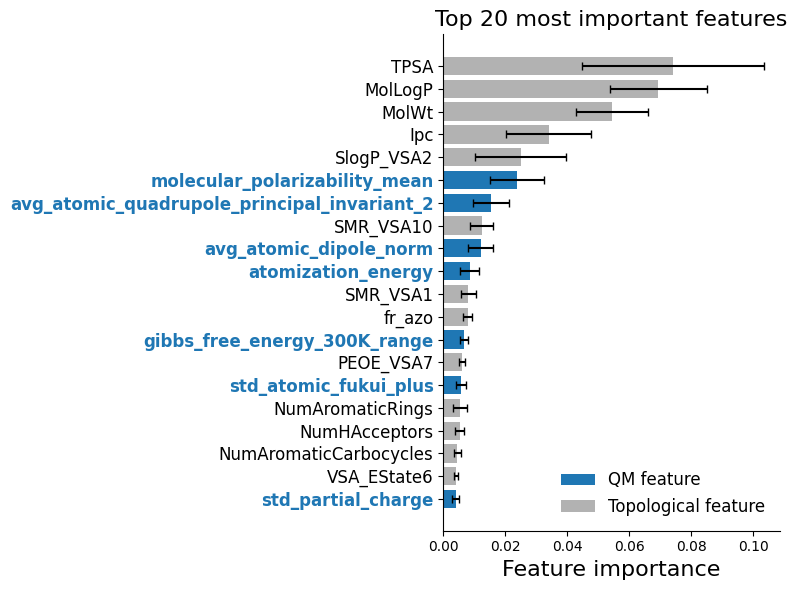

------ size = 0.9 ------


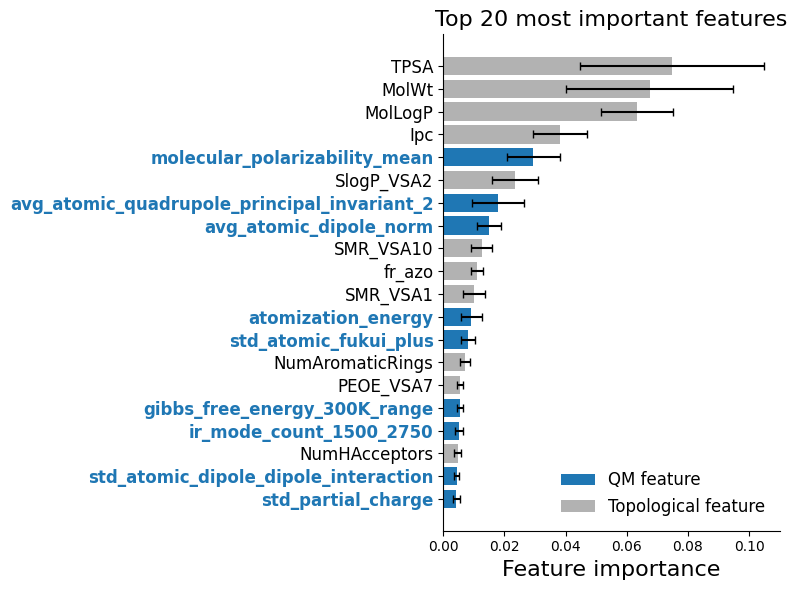

------ size = 1.0 ------


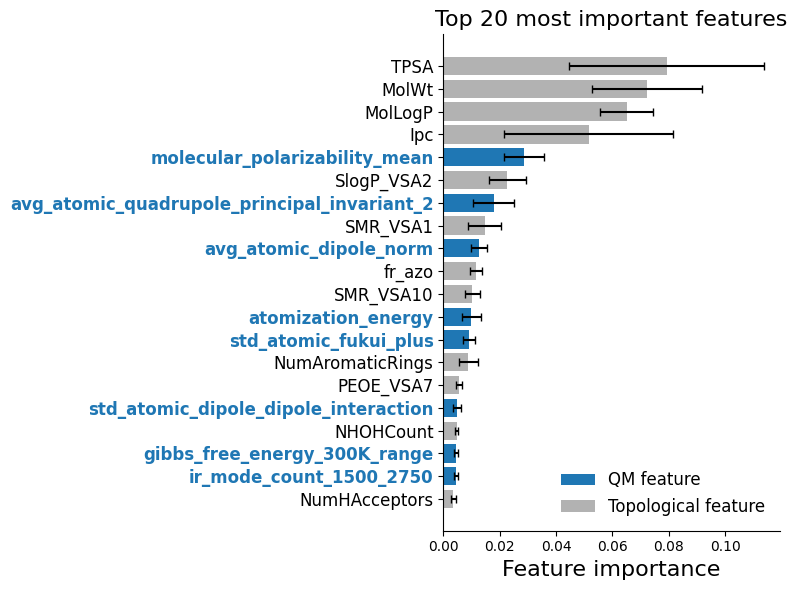

In [78]:
file = Path(r"..\data\KRR_results\2_KRR_combo_filtered_PFI_results.csv")
krr_combo_fi_df = pd.read_csv(file)
grouped = krr_combo_fi_df[
    krr_combo_fi_df["fold_id"]
    .isin(KRR_combo_filtered_df_pos.fold_id.unique())
    ].groupby("size")

for size in KRR_plot_df.index:
    print(f"------ {size = } ------")
    
    data = grouped.get_group(size)
    groups = data[["fold_id", "feature", "r2_mean"]]

    FI_dict = {
        fold_id: df.set_index("feature")["r2_mean"]
        for fold_id, df in groups.groupby("fold_id")
    }

    FI = FeatureImportance(
        krr_combo_groups.get_group(size).reset_index(drop=True),
        provided_FI=FI_dict
    )
    fi_df = FI.get_feature_importance(20)
    FI.plot(20)

### Huber Regression

In [34]:
HuberReg_combined_df = make_combined_df(HuberReg_combo_filtered_df_pos, HuberReg_topo_filtered_df_pos)
HuberReg_plot_df = HuberReg_combined_df
HuberReg_plot_df

,combo_mean,combo_std,topo_mean,topo_std,diff,num_samples,num_scores
size,,,,,,,
0.025,0.084543,0.023255,0.291432,0.047642,0.206889,219,2
0.050,0.341573,0.186974,0.376138,0.101853,0.034565,438,3
0.075,0.380117,0.110897,0.527622,0.160384,0.147504,657,7
0.100,0.449627,0.218761,0.666224,0.082006,0.216597,876,9
0.150,0.646386,0.136606,0.713768,0.112797,0.067382,1314,13
0.200,0.697645,0.100132,0.736632,0.122223,0.038986,1752,21
0.250,0.738231,0.082991,0.739456,0.140591,0.001226,2190,24
0.500,0.798154,0.056023,0.780534,0.089955,0.017620,4381,25
0.600,0.804398,0.042151,0.779628,0.103595,0.024771,5257,24


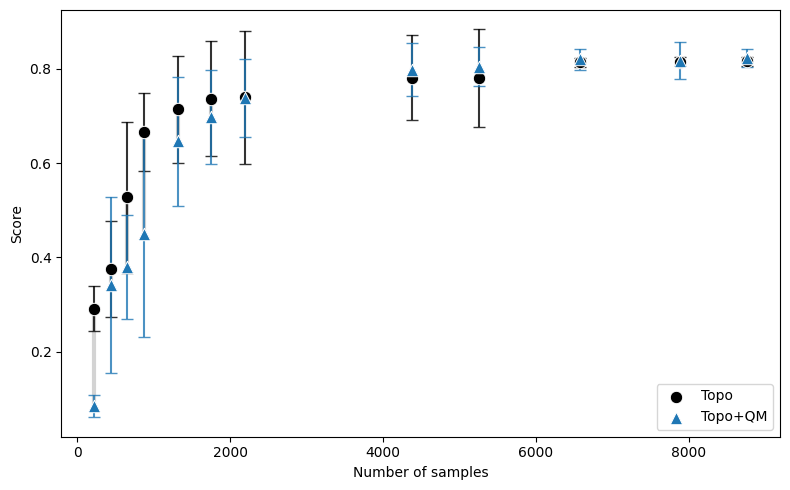

In [35]:
plot_size_evo(HuberReg_plot_df)

### Chemprop

In [53]:
for id, group in chemprop_baseline_df.groupby("fold_id"):
    if id in (21, 22, 23):
        display(group)
    print(id, len(group))

# 21 900, 23 100

0 12
1 12
2 12
3 12
4 12
5 12
6 12
7 12
8 12
9 12
10 12
11 12
12 12
13 12
14 12
15 12
16 12
17 12
18 12
19 12
20 12


,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers
156,21,0.025,0.589932,0.392737,145,5,329,3
157,21,0.050,0.725679,0.279688,251,4,134,3
158,21,0.075,0.758147,0.232787,194,3,325,3
159,21,0.150,0.756312,0.232485,187,5,329,5
160,21,0.100,0.712269,0.278134,194,1,401,5
161,21,0.250,0.791597,0.195727,455,4,101,5
162,21,0.200,0.782185,0.207526,348,5,428,2
163,21,0.500,0.826349,0.162213,489,5,396,5
164,21,0.600,0.844775,0.144265,419,5,387,5
165,21,0.750,0.838873,0.150234,421,5,232,2


21 11


,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers
167,22,0.025,0.675952,0.336493,251,4,134,3
168,22,0.050,0.723378,0.292753,447,5,329,4
169,22,0.075,0.739872,0.280716,395,5,384,1
170,22,0.150,0.791700,0.218544,329,4,356,3
171,22,0.100,0.762279,0.249622,100,3,223,5
172,22,0.250,0.806043,0.198835,395,5,429,2
173,22,0.200,0.795208,0.211016,259,5,143,2
174,22,0.500,0.812034,0.195211,302,5,359,4
175,22,0.600,0.836130,0.168590,370,5,186,5
176,22,0.750,0.837751,0.167919,395,5,429,2


22 12


,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers
179,23,0.025,0.613669,0.411935,360,5,161,4
180,23,0.050,0.667343,0.343981,446,4,370,1
181,23,0.075,0.749102,0.257867,238,3,216,3
182,23,0.150,0.808550,0.198444,395,5,429,2
183,23,0.250,0.800707,0.207384,489,5,396,5
184,23,0.200,0.787807,0.221323,277,5,390,1
185,23,0.500,0.813546,0.193763,438,5,237,3
186,23,0.600,0.841489,0.165357,434,5,223,5
187,23,0.750,0.858048,0.146666,368,5,498,5
188,23,0.900,0.860162,0.143969,114,3,324,3


23 11
24 12


In [69]:
combo_df = make_combined_df(chemprop_atom_df, chemprop_rdkit_df, "r2_test")
combo_df1 = make_combined_df(chemprop_full_df, chemprop_rdkit_df, "r2_test")
combo_df1 = make_combined_df(chemprop_full_df, chemprop_rdkit_df, "r2_test")
combo_df

,combo_mean,combo_std,topo_mean,topo_std,diff,num_samples,num_scores
size,,,,,,,
0.025,0.694783,0.020435,0.711631,0.034958,0.016849,219,25
0.050,0.735835,0.021259,0.752711,0.019630,0.016877,438,25
0.075,0.754571,0.017901,0.768609,0.046072,0.014039,657,25
0.100,0.770599,0.016170,0.789655,0.016487,0.019056,876,25
0.150,0.790352,0.015678,0.809545,0.014832,0.019193,1314,25
0.200,0.794421,0.029096,0.821201,0.010689,0.026780,1752,25
0.250,0.807069,0.016009,0.831107,0.013177,0.024038,2190,25
0.500,0.830621,0.016233,0.848749,0.012754,0.018128,4381,25
0.600,0.837754,0.016640,0.858594,0.009000,0.020840,5257,25


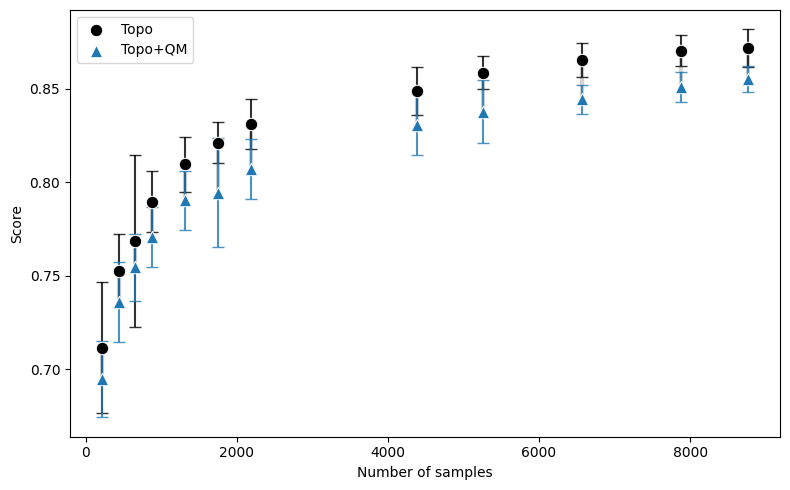

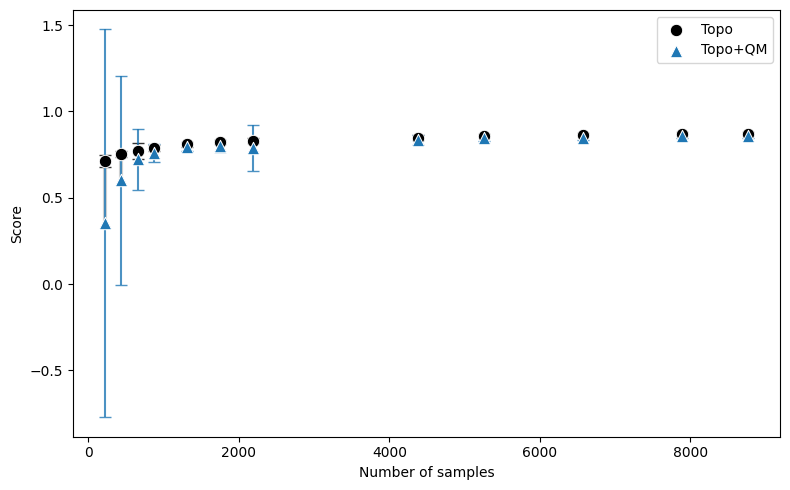

In [70]:
plot_size_evo(combo_df)
plot_size_evo(combo_df1)
# plt.ylim(0, 1)
# plt.xscale("log")